DataFrame 'df' not found. Attempting to load 'SPE_shale_original - copia.xlsx'.
DataFrame 'df' loaded successfully.


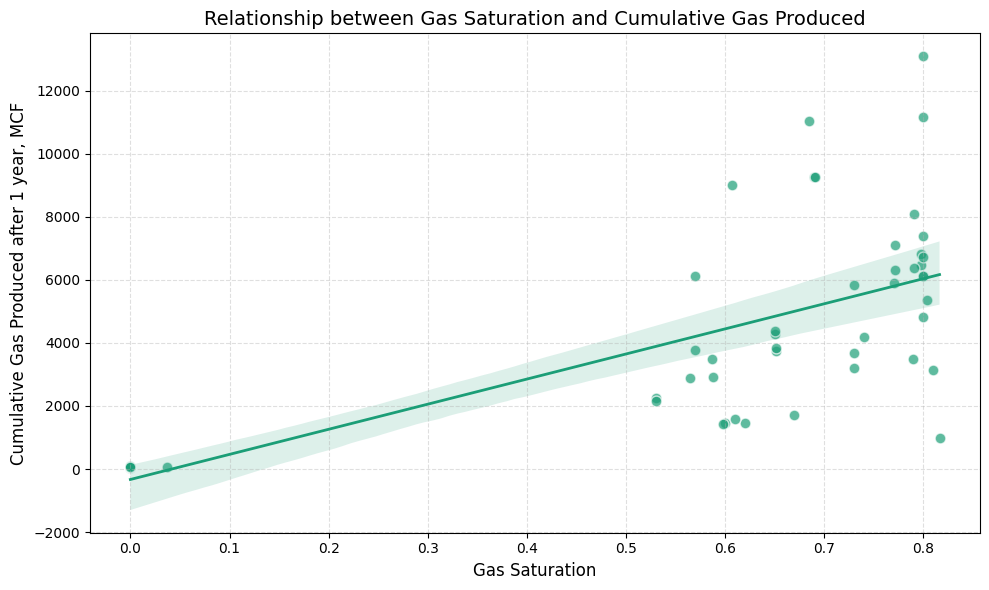

In [ ]:
# ============================================
# 12) Relación con la variable objetivo
#    y saturacion de Gas
# ============================================


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Import pandas to read the Excel file

# Load the dataset if 'df' is not defined
# Assuming the Excel file is in the content directory
try:
    df
except NameError:
    print("DataFrame 'df' not found. Attempting to load 'SPE_shale_original - copia.xlsx'.")
    try:
        df = pd.read_excel('/content/SPE_shale_original - copia.xlsx')
        print("DataFrame 'df' loaded successfully.")
    except FileNotFoundError:
        print("Error: 'SPE_shale_original - copia.xlsx' not found. Please ensure the file is in '/content/'.")
        # Exit or handle the error appropriately if the file isn't found
    except Exception as e:
        print(f"An error occurred while loading the DataFrame: {e}")

# Clean up column names by stripping whitespace
df.columns = df.columns.str.strip()

TEAL = "#1b9e77"

plt.figure(figsize=(10, 6))
sns.regplot(
    x='Gas Saturation',
    y='Cumulative Gas Produced after 1 year, MCF',
    data=df,
    scatter_kws={'color': TEAL, 'alpha': 0.7, 's': 60, 'edgecolor': 'white'},
    line_kws={'color': TEAL, 'linewidth': 2}
)

plt.title('Relationship between Gas Saturation and Cumulative Gas Produced', fontsize=14)
plt.xlabel('Gas Saturation', fontsize=12)
plt.ylabel('Cumulative Gas Produced after 1 year, MCF', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# 13) Analisis PCA
# ============================================

from sklearn.preprocessing import StandardScaler
import pandas as pd # Ensure pandas is imported
import numpy as np # Ensure numpy is imported for select_dtypes

# Define the target variable for predictive modeling
target_variable = 'Cumulative Gas Produced after 1 year, MCF'

# Define petrophysical and completion variables, stripping whitespace from names
petrophysical_variables = [col.strip() for col in ['Porosity', ' Gas Saturation ', ' Oil Saturation ', ' Water Saturation ', ' Gas Specific Gravity ', ' Net Pay (ft)', 'CO₂','N₂']]

completion_variables = [col.strip() for col in ['# Stages', '# Clusters ', '# of Total Proppant (MM Lbs)', ' Lateral Length (ft)', 'Bottom Perf (ft)', 'Top Perf (ft) ']]

# NOTE: Formation columns are explicitly excluded as per user request.
# formation_encoded_cols = [col for col in df.columns if 'Formation_' in col]
# petrophysical_variables.extend(formation_encoded_cols)

# Combine these into the features for PCA
features_for_pca = petrophysical_variables + completion_variables

# Filter out any columns that might not exist in the DataFrame
features_for_pca = [col for col in features_for_pca if col in df.columns]

X = df[features_for_pca]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data standardized successfully. Shape of scaled data:", X_scaled.shape)

Data standardized successfully. Shape of scaled data: (50, 12)


La selección de variables para el análisis PCA y los modelos predictivos se centró exclusivamente en variables petrofísicas y de completamiento debido a que representan los factores que tienen una relación directa, cuantificable y físicamente fundamentada con el desempeño productivo del pozo.

Las **variables petrofísicas** como Porosity, Gas Saturation, Water Saturation, Oil Saturation, Gas Specific Gravity, Net Pay, CO₂ y N₂ describen la calidad de la roca y del fluido en el yacimiento, factores que determinan la capacidad de almacenamiento y movilidad del gas.

las **variables de completamiento** como # Stages, # Clusters, Total Proppant, Lateral Length, Bottom Perf y Top Perf representan la intensidad del diseño de estimulación, directamente relacionada con el volumen de roca estimulado y la eficiencia del drenaje.

Las demás variables fueron descartadas para el PCA y el modelamiento debido a que no aportan variabilidad significativa, son de tipo identificativo o categórico, o bien describen ubicación geográfica u operativa sin relacionarse de manera directa con el mecanismo físico de producción. Además, algunas de ellas generan ruido estadístico, aumentan la multicolinealidad o no cumplen con los requisitos de continuidad necesarios para un PCA. Al limitar el análisis a las variables petrofísicas y de completamiento, se garantiza un modelo más estable, interpretable y estadísticamente robusto, centrado en los factores que realmente controlan la productividad del pozo y evitando incluir información irrelevante o redundante.


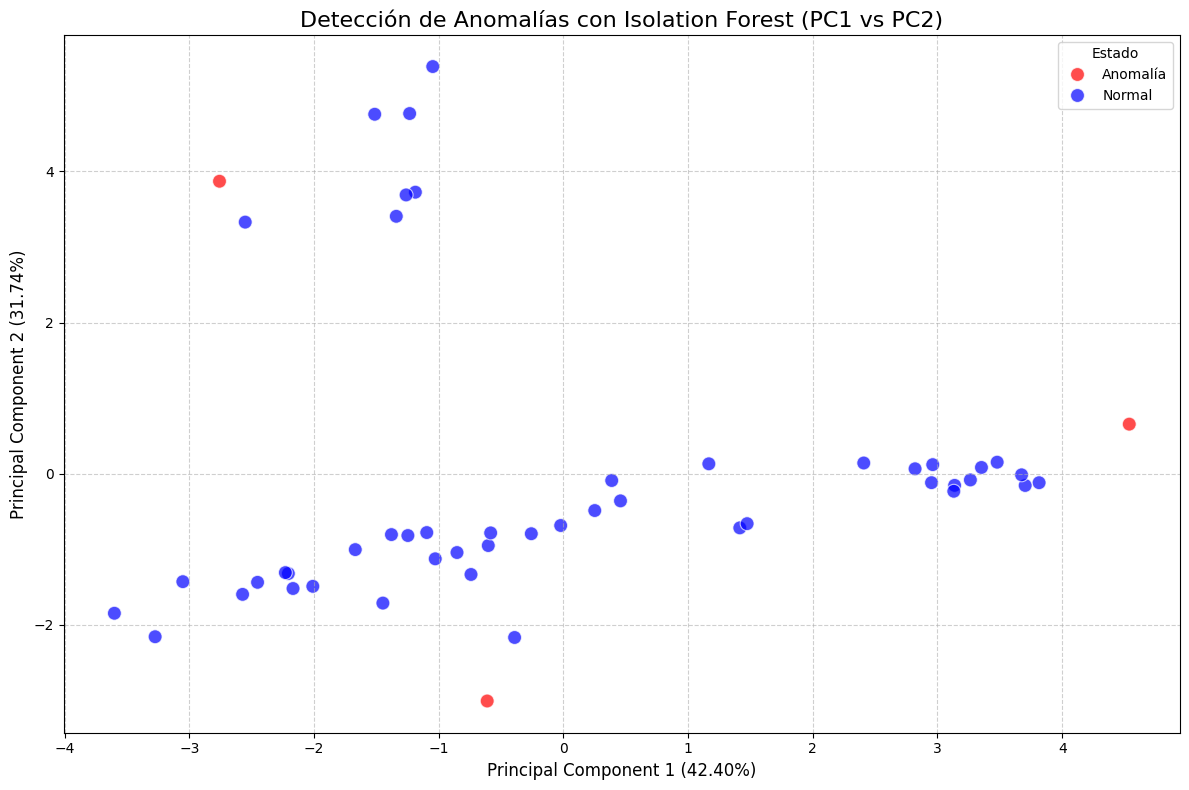

In [ ]:
# Analisis isolation Forest(Deteccion de anomalias)


from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA # Import PCA

# Assuming X_scaled and num_components_95 are already defined from previous steps
# Re-apply PCA with the determined number of components
pca_final = PCA(n_components=num_components_95) # num_components_95 was determined in a previous step
X_pca = pca_final.fit_transform(X_scaled)

# Inicializar el modelo Isolation Forest
# 'contamination' es la proporción esperada de outliers en el dataset.
# Si no tienes una estimación, puedes probar diferentes valores o dejar el valor por defecto ('auto').
# Usaremos random_state para reproducibilidad.
iso_forest = IsolationForest(contamination=0.05, random_state=42) # Se asume un 5% de anomalías

# Entrenar el modelo y predecir las anomalías
# fit_predict devuelve -1 para outliers y 1 para inliers
anomaly_predictions = iso_forest.fit_predict(X_pca)

# Añadir las predicciones al DataFrame de PCA para visualización
pca_df_anomalies = pd.DataFrame(data=X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
pca_df_anomalies['Anomaly'] = anomaly_predictions

# Convertir las etiquetas numéricas a algo más descriptivo para el hue del plot
pca_df_anomalies['Anomaly_Label'] = pca_df_anomalies['Anomaly'].map({1: 'Normal', -1: 'Anomalía'})

# Visualizar los resultados
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Anomaly_Label',
    palette={'Normal': 'blue', 'Anomalía': 'red'},
    data=pca_df_anomalies,
    s=100,
    alpha=0.7,
    edgecolor='w'
)

plt.title('Detección de Anomalías con Isolation Forest (PC1 vs PC2)', fontsize=16)
plt.xlabel(f'Principal Component 1 ({pca_final.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca_final.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
plt.legend(title='Estado')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

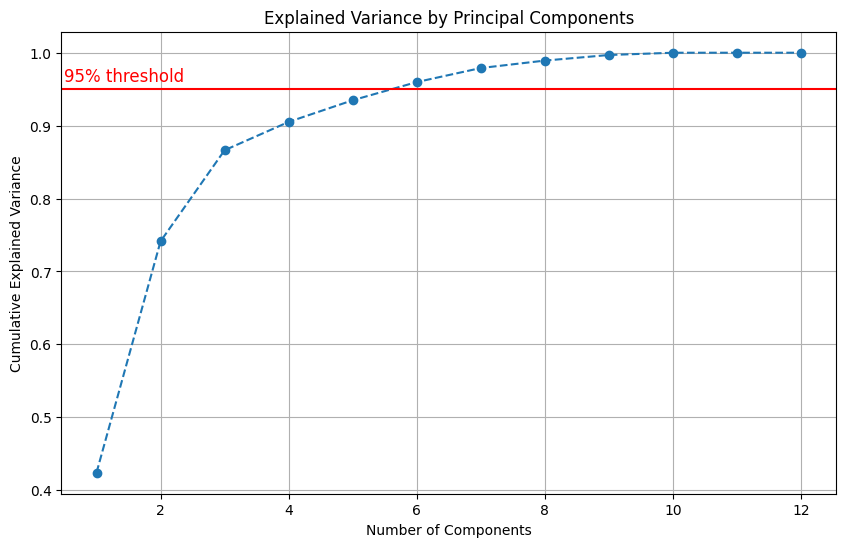

Number of components to retain to explain 95% of variance: 6


In [ ]:
# Grafico de Varianza vs componentes necesarios

from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Apply PCA
pca = PCA()
pca.fit(X_scaled)

# Calculate cumulative explained variance
cum_exp_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_exp_variance) + 1), cum_exp_variance, marker='o', linestyle='--')
plt.title('Explained Variance by Principal Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)

# Add horizontal line at 95% variance threshold
plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(0.5, 0.96, '95% threshold', color = 'red', fontsize=12)

plt.show()

# Determine the number of components to retain (e.g., to explain 95% of variance)
num_components_95 = np.where(cum_exp_variance >= 0.95)[0][0] + 1
print(f"Number of components to retain to explain 95% of variance: {num_components_95}")

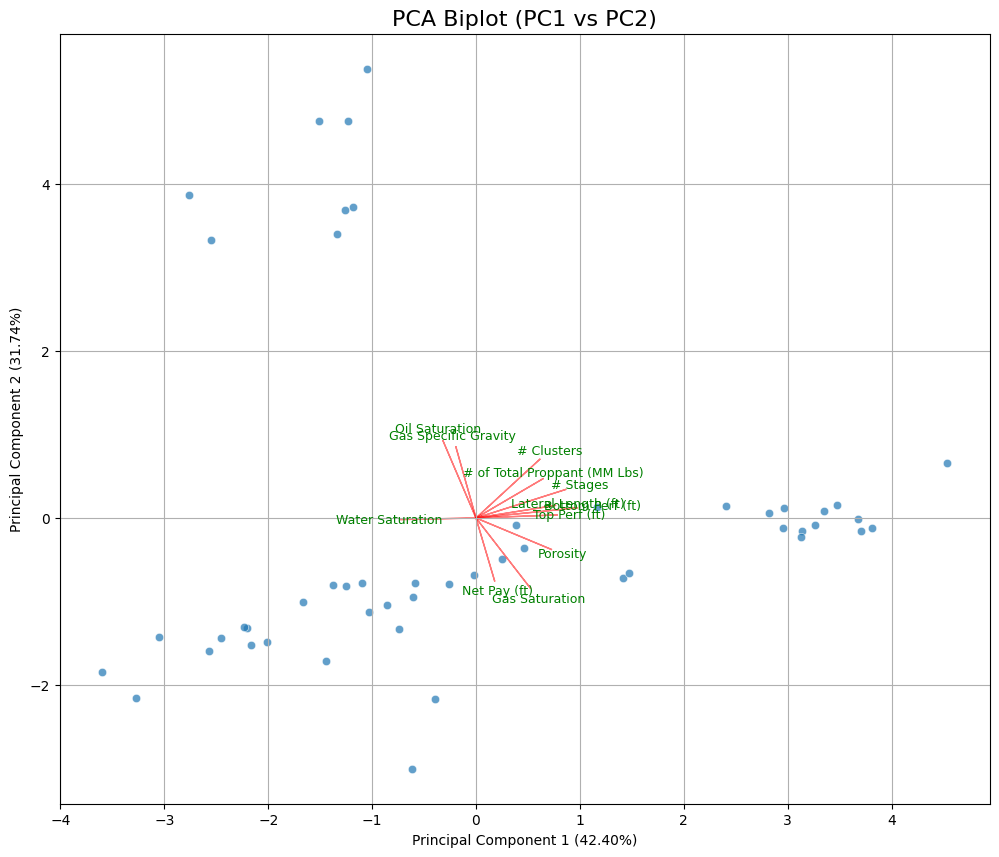

In [ ]:
# Grafico de PCA (PC1 vs PC2)


from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Re-apply PCA with the determined number of components (8 components for 95% variance)
pca_final = PCA(n_components=num_components_95) # num_components_95 was determined in the previous step
X_pca = pca_final.fit_transform(X_scaled)

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(data=X_pca, columns=[f'PC{i+1}' for i in range(num_components_95)])

# Get the loadings (eigenvectors) of the principal components
loadings = pca_final.components_.T * np.sqrt(pca_final.explained_variance_)

# Create a DataFrame for loadings for easier plotting
loadings_df = pd.DataFrame(loadings, index=features_for_pca, columns=[f'PC{i+1}' for i in range(num_components_95)])

# Create the biplot
plt.figure(figsize=(12, 10))
sns.scatterplot(x='PC1', y='PC2', data=pca_df, alpha=0.7)

# Plot arrows for loadings
for i, feature in enumerate(features_for_pca):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], color='r', alpha=0.5)
    plt.text(loadings[i, 0]*1.15, loadings[i, 1]*1.15, feature, color='g', ha='center', va='center', fontsize=9)

plt.xlabel(f'Principal Component 1 ({pca_final.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca_final.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('PCA Biplot (PC1 vs PC2)', fontsize=16)
plt.grid()
plt.show()



**PC1**: Resume principalmente la intensidad del completamiento y la calidad de la roca. En el biplot se observa que # Stages, # Clusters, Total Proppant (MM Lbs), Lateral Length (ft) y Porosity apuntan hacia valores positivos de PC1, lo que indica que este componente distingue pozos con completamientos más robustos (más etapas, mayor densidad de disparos y mayor volumen de propante) y mejores propiedades petrofísicas. Esto coincide con la idea de que más etapas y más propante generan fracturas más grandes y mayor superficie de contacto, mientras que laterales más largos permiten drenar mayor volumen de roca. En la dirección opuesta aparecen Water Saturation y Gas Saturation, variables que se proyectan hacia valores negativos de PC1 y que se asocian a condiciones menos favorables en términos de calidad de roca y potencial de drenaje.

**PC2**: Captura diferencias asociadas principalmente al régimen de fluidos y a la composición interna del sistema. Las variables Oil Saturation y Gas Specific Gravity muestran cargas positivas importantes, lo que sugiere una mayor influencia de fracciones líquidas y gas más pesado en los pozos situados hacia valores altos de PC2. En contraste, Gas Saturation y Net Pay (ft) se proyectan hacia valores negativos de este componente, indicando pozos con gas más seco y mayor espesor neto productivo. En conjunto, PC2 complementa la caracterización del sistema al distinguir entre pozos con mezclas de fluidos más complejas (húmedas o pesadas) y pozos dominados por gas seco y mayor volumen de roca disponible.


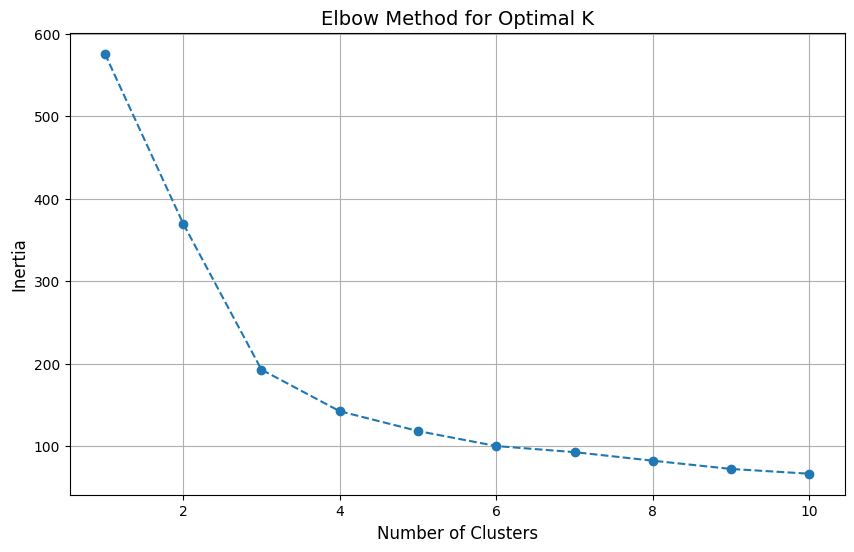

In [ ]:
# ============================================
# 14) Clustering Método del codo (encontrar el numero de clusters por K)
# Metodo Elbow
# ============================================


from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Create an empty list to store inertia values
inertia_values = []

# Loop through a range of possible cluster numbers (e.g., from 1 to 10)
for i in range(1, 11): # Testing K from 1 to 10
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto') # n_init='auto' for KMeans warnings
    kmeans.fit(X_pca)
    inertia_values.append(kmeans.inertia_)

# Plot the inertia values against the range of cluster numbers
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia_values, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K', fontsize=14)
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.grid(True)
plt.show()



In [ ]:
optimal_k = 3 # Based on visual inspection of the Elbow Method plot

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
clusters = kmeans_final.fit_predict(X_pca)

print(f"K-Means clustering applied with optimal K = {optimal_k}.")
print(f"Cluster assignments for the first 5 data points: {clusters[:5]}")

K-Means clustering applied with optimal K = 3.
Cluster assignments for the first 5 data points: [2 2 2 2 2]


**MODELO K-MEANS CLUSTERING**

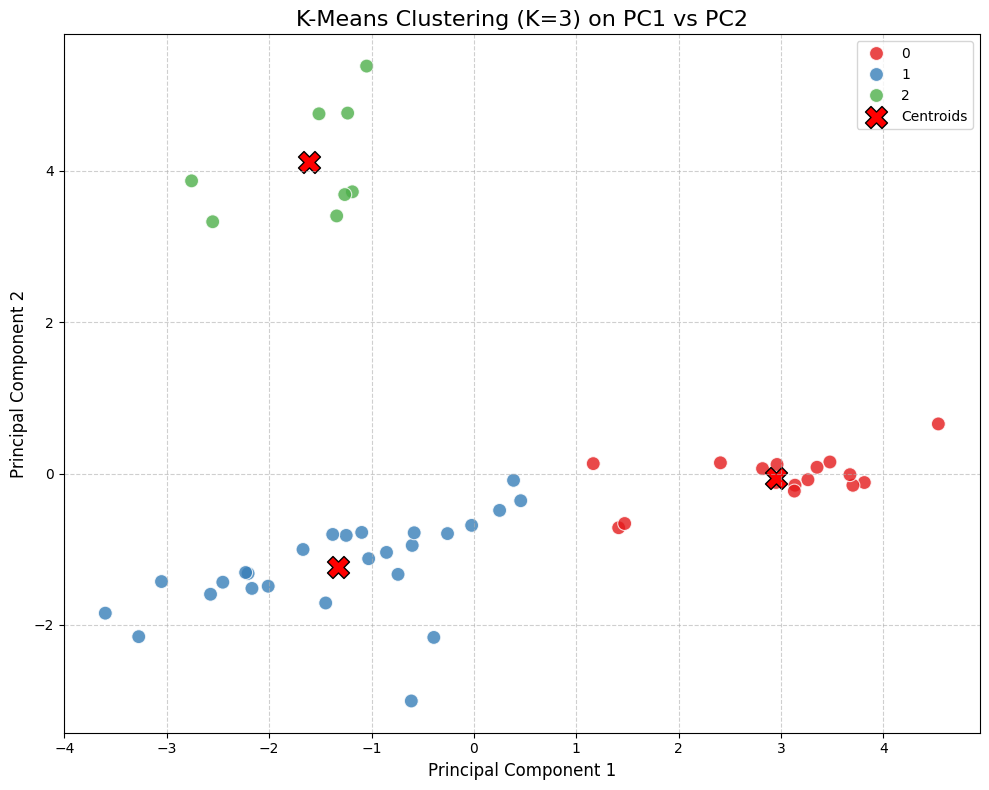

K-Means clusters with centroids visualized on PC1 vs PC2 plot for K = 3.


In [ ]:
# Grafico de K Means por centroides

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define a custom color palette for consistency
custom_palette = sns.color_palette("Set1", 3) # Using Set1 palette with 3 colors

# Create a DataFrame for PCA results with cluster assignments
pca_df_clusters = pd.DataFrame(data=X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
pca_df_clusters['Cluster'] = clusters

# Get cluster centroids
centroids = kmeans_final.cluster_centers_

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df_clusters,
    palette=custom_palette, # Apply the custom palette
    s=100,
    alpha=0.8,
    edgecolor='w'
)

# Plot centroids
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=250,
    color='red',
    label='Centroids',
    edgecolor='black'
)

plt.title(f'K-Means Clustering (K={optimal_k}) on PC1 vs PC2', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"K-Means clusters with centroids visualized on PC1 vs PC2 plot for K = {optimal_k}.")

El análisis de clústeres muestra una separación muy marcada por formación.
**El clúster rojo** (cluster 0) está compuesto casi en su totalidad por pozos de Haynesville Shale (93.3%) con una presencia marginal de Bossier Shale (6.7%), sin incluir pozos de Eagle Ford ni Marcellus.
**El clúster azul** (cluster 1) agrupa exclusivamente pozos de Marcellus (40.7%) y Marcellus Upper (59.3%)
**El clúster verde** (cluster 2) está formado en un 100% por pozos de Eagle Ford. Estos resultados indican que la segmentación por K-Means refleja de manera consistente las diferencias geológicas entre formaciones , mostrando que cada grupo conserva una identidad litológica bien delimitada. Además, la ubicación de los centroides dentro del plano PC1–PC2 confirma que los clústeres no solo difieren en formación, sino también en el comportamiento multivariado de las propiedades petrofísicas y de completamiento asociadas a cada uno de ellos.

**MODELO JERARQUICO CLUSTERING**

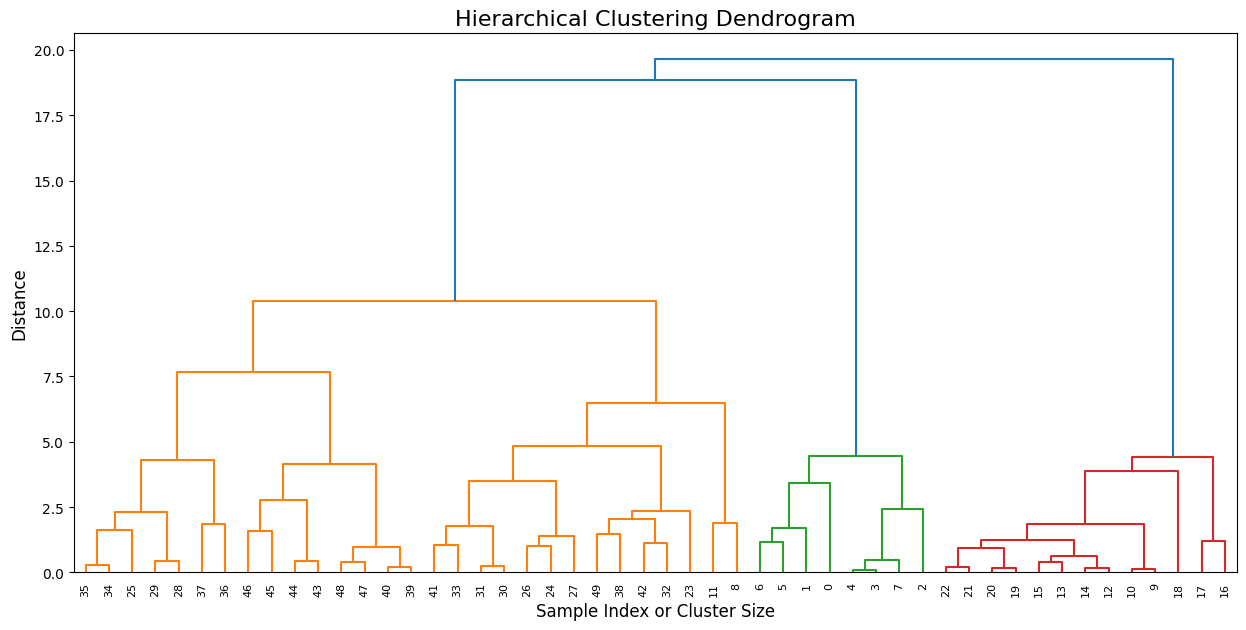

In [ ]:
# Agrupamiento Jerarquico (Dendograma):

from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Compute the linkage matrix using the 'ward' method
linked_data = linkage(X_pca, method='ward')

# Plot the dendrogram
plt.figure(figsize=(15, 7))
dendrogram(
    linked_data,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True
)
plt.title('Hierarchical Clustering Dendrogram', fontsize=16)
plt.xlabel('Sample Index or Cluster Size', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.show()

El **Dendrograma:** representa cómo los pozos se agrupan según su similitud multivariable mediante clustering jerárquico. En este tipo de gráfico:

**El eje X** no corresponde a ninguna variable de la base de datos, sino simplemente al orden secuencial de las muestras (índices de pozos) después del procesamiento, lo que permite visualizar cada pozo como una hoja en la base del dendrograma.

**El eje Y** muestra la altura o distancia de fusión entre los grupos; estos valores son generados matemáticamente por el algoritmo a partir de las distancias entre pozos ya estandarizados y no representan números presentes en el archivo original. Una mayor altura implica que los grupos que se unen en ese punto son más diferentes entre sí. En este caso, la estructura del dendrograma evidencia que las fusiones principales ocurren a alturas relativamente altas (del orden de ~18 a ~20), lo que indica que existen tres grupos bien separados, coherentes con los clústeres identificados previamente mediante K‑Means.

In [ ]:
from scipy.cluster.hierarchy import fcluster
import numpy as np

# Assuming an optimal number of clusters (e.g., 3) based on the dendrogram analysis
# The 'max_d' parameter in fcluster refers to the criterion for forming flat clusters.
# If criterion is 'maxclust', max_d is interpreted as the number of clusters.
optimal_hierarchical_k = 3 # Based on visual inspection of the dendrogram

hierarchical_clusters = fcluster(linked_data, optimal_hierarchical_k, criterion='maxclust')

print(f"Hierarchical clustering applied with {optimal_hierarchical_k} clusters.")
print(f"Cluster assignments for the first 5 data points: {hierarchical_clusters[:5]}")

Hierarchical clustering applied with 3 clusters.
Cluster assignments for the first 5 data points: [2 2 2 2 2]


**MODELO RANDOM FOREST**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df[features_for_pca] # Using features_for_pca which includes petrophysical, completion, and encoded formation variables
y = df[target_variable]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions on the test set for this model
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model (for comparison later)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# 1. Extract feature importances
feature_importances = rf_model.feature_importances_

# 2. Create a Pandas Series mapping feature names to importance scores
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importances
})

# Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

print("Random Forest Regressor (All Features) Model Evaluation:")
print(f"  Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"  R-squared (R2): {r2_rf:.2f}")

print("\nFeature Importances (all features):")
print(feature_importance_df)

Random Forest Regressor (All Features) Model Evaluation:
  Mean Squared Error (MSE): 3188864.38
  Root Mean Squared Error (RMSE): 1785.74
  R-squared (R2): 0.59

Feature Importances (all features):
                         feature  importance
10              Bottom Perf (ft)    0.189106
9            Lateral Length (ft)    0.176835
0                       Porosity    0.171168
1                 Gas Saturation    0.103761
5                   Net Pay (ft)    0.088289
6                       # Stages    0.060631
3               Water Saturation    0.047395
2                 Oil Saturation    0.042444
8   # of Total Proppant (MM Lbs)    0.032044
11                 Top Perf (ft)    0.030479
4           Gas Specific Gravity    0.030103
7                     # Clusters    0.027745


In [ ]:
# SE IDENTIFICAN LAS 8 VARIABLES MAS IMPORTANTES ENTRE
#PROPIEDADES PETROFISICAS Y DE COMPLETAMIENTO

# 3. Identify and select the top 8 most important features
top_8_features = feature_importance_df['feature'].head(8).tolist()
print(f"Top 8 most important features: {top_8_features}")

# 4. Create new training and testing feature sets
X_train_top8 = X_train[top_8_features]
X_test_top8 = X_test[top_8_features]

# 5. Initialize a new RandomForestRegressor with the same parameters
rf_model_top8 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 6. Train this new model
rf_model_top8.fit(X_train_top8, y_train)

# 7. Make predictions on X_test_top8
y_pred_rf_top8 = rf_model_top8.predict(X_test_top8)

# 8. Calculate and print the evaluation metrics
mse_rf_top8 = mean_squared_error(y_test, y_pred_rf_top8)
rmse_rf_top8 = np.sqrt(mse_rf_top8)
r2_rf_top8 = r2_score(y_test, y_pred_rf_top8)

print(f"\nRandom Forest Regressor (Top 8 Features) Model Evaluation:")
print(f"  Mean Squared Error (MSE): {mse_rf_top8:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf_top8:.2f}")
print(f"  R-squared (R2): {r2_rf_top8:.2f}")


Top 8 most important features: ['Bottom Perf (ft)', 'Lateral Length (ft)', 'Porosity', 'Gas Saturation', 'Net Pay (ft)', '# Stages', 'Water Saturation', 'Oil Saturation']

Random Forest Regressor (Top 8 Features) Model Evaluation:
  Mean Squared Error (MSE): 2897310.47
  Root Mean Squared Error (RMSE): 1702.15
  R-squared (R2): 0.62


**MODELO DE REGRESION MULTIPLE**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize the Multiple Linear Regression model
mlr_model_top8 = LinearRegression()

# Train the model using X_train_top8 and y_train
mlr_model_top8.fit(X_train_top8, y_train)

# Make predictions on the test set
y_pred_mlr_top8 = mlr_model_top8.predict(X_test_top8)

# Evaluate the model
mse_mlr_top8 = mean_squared_error(y_test, y_pred_mlr_top8)
rmse_mlr_top8 = np.sqrt(mse_mlr_top8)
r2_mlr_top8 = r2_score(y_test, y_pred_mlr_top8)

print(f"Multiple Linear Regression Model (Top 8 Features) Evaluation:")
print(f"  Mean Squared Error (MSE): {mse_mlr_top8:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_mlr_top8:.2f}")
print(f"  R-squared (R2): {r2_mlr_top8:.2f}")

print("\nModel Coefficients (Top 8 Features):")
for feature, coef in zip(X_train_top8.columns, mlr_model_top8.coef_):
    print(f"  {feature}: {coef:.2f}")
print(f"  Intercept: {mlr_model_top8.intercept_:.2f}")

Multiple Linear Regression Model (Top 8 Features) Evaluation:
  Mean Squared Error (MSE): 4081684.06
  Root Mean Squared Error (RMSE): 2020.32
  R-squared (R2): 0.47

Model Coefficients (Top 8 Features):
  Bottom Perf (ft): -0.25
  Lateral Length (ft): 0.39
  Porosity: 128549.35
  Gas Saturation: 1048.74
  Net Pay (ft): -18.46
  # Stages: 71.98
  Water Saturation: 5277.82
  Oil Saturation: -6326.55
  Intercept: -5173.35


**MODELO XG BOOST**

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize the XGBoost Regressor model
# You can tune hyperparameters like n_estimators, learning_rate, max_depth
xgb_model_top8 = xgb.XGBRegressor(
    objective='reg:squarederror', # Objective for regression tasks
    n_estimators=100,             # Number of boosting rounds
    learning_rate=0.1,            # Step size shrinkage
    max_depth=5,                  # Maximum depth of a tree
    random_state=42,              # For reproducibility
    n_jobs=-1                     # Use all available cores
)

# Train the model
xgb_model_top8.fit(X_train_top8, y_train)

# Make predictions on the test set
y_pred_xgb_top8 = xgb_model_top8.predict(X_test_top8)

# Evaluate the model
mse_xgb_top8 = mean_squared_error(y_test, y_pred_xgb_top8)
rmse_xgb_top8 = np.sqrt(mse_xgb_top8)
r2_xgb_top8 = r2_score(y_test, y_pred_xgb_top8)

print(f"XGBoost Regressor Model (Top 8 Features) Evaluation:")
print(f"  Mean Squared Error (MSE): {mse_xgb_top8:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_xgb_top8:.2f}")
print(f"  R-squared (R2): {r2_xgb_top8:.2f}")

XGBoost Regressor Model (Top 8 Features) Evaluation:
  Mean Squared Error (MSE): 4943094.10
  Root Mean Squared Error (RMSE): 2223.31
  R-squared (R2): 0.36


### **MODELO LASSO REGRESSION**

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize the Lasso Regressor model for top 8 features
# Alpha is the regularization strength; you might need to tune this.
lasso_model_top8 = Lasso(alpha=1.0, random_state=42)

# Train the model
lasso_model_top8.fit(X_train_top8, y_train)

# Make predictions on the test set
y_pred_lasso_top8 = lasso_model_top8.predict(X_test_top8)

# Evaluate the model
mse_lasso_top8 = mean_squared_error(y_test, y_pred_lasso_top8)
rmse_lasso_top8 = np.sqrt(mse_lasso_top8)
r2_lasso_top8 = r2_score(y_test, y_pred_lasso_top8)

print(f"Lasso Regressor Model (Top 8 Features) Evaluation:")
print(f"  Mean Squared Error (MSE): {mse_lasso_top8:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_lasso_top8:.2f}")
print(f"  R-squared (R2): {r2_lasso_top8:.2f}")

print("\nModel Coefficients (Top 8 Features, Lasso):")
for feature, coef in zip(X_train_top8.columns, lasso_model_top8.coef_):
    print(f"  {feature}: {coef:.2f}")
print(f"  Intercept: {lasso_model_top8.intercept_:.2f}")

Lasso Regressor Model (Top 8 Features) Evaluation:
  Mean Squared Error (MSE): 3450026.58
  Root Mean Squared Error (RMSE): 1857.42
  R-squared (R2): 0.55

Model Coefficients (Top 8 Features, Lasso):
  Bottom Perf (ft): -0.19
  Lateral Length (ft): 0.31
  Porosity: 98489.85
  Gas Saturation: 0.00
  Net Pay (ft): -19.05
  # Stages: 72.30
  Water Saturation: 2338.96
  Oil Saturation: -8151.16
  Intercept: -1816.97


### **MODELO RIDGE**

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize the Ridge Regressor model for top 8 features
# Alpha is the regularization strength; you might need to tune this.
ridge_model_top8 = Ridge(alpha=1.0, random_state=42)

# Train the model
ridge_model_top8.fit(X_train_top8, y_train)

# Make predictions on the test set
y_pred_ridge_top8 = ridge_model_top8.predict(X_test_top8)

# Evaluate the model
mse_ridge_top8 = mean_squared_error(y_test, y_pred_ridge_top8)
rmse_ridge_top8 = np.sqrt(mse_ridge_top8)
r2_ridge_top8 = r2_score(y_test, y_pred_ridge_top8)

print(f"Ridge Regressor Model (Top 8 Features) Evaluation:")
print(f"  Mean Squared Error (MSE): {mse_ridge_top8:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_ridge_top8:.2f}")
print(f"  R-squared (R2): {r2_ridge_top8:.2f}")

print("\nModel Coefficients (Top 8 Features, Ridge):")
for feature, coef in zip(X_train_top8.columns, ridge_model_top8.coef_):
    print(f"  {feature}: {coef:.2f}")
print(f"  Intercept: {ridge_model_top8.intercept_:.2f}")

Ridge Regressor Model (Top 8 Features) Evaluation:
  Mean Squared Error (MSE): 2543072.47
  Root Mean Squared Error (RMSE): 1594.70
  R-squared (R2): 0.67

Model Coefficients (Top 8 Features, Ridge):
  Bottom Perf (ft): 0.08
  Lateral Length (ft): 0.06
  Porosity: 279.07
  Gas Saturation: 3722.43
  Net Pay (ft): -9.58
  # Stages: 67.15
  Water Saturation: -45.02
  Oil Saturation: -3677.41
  Intercept: -790.39


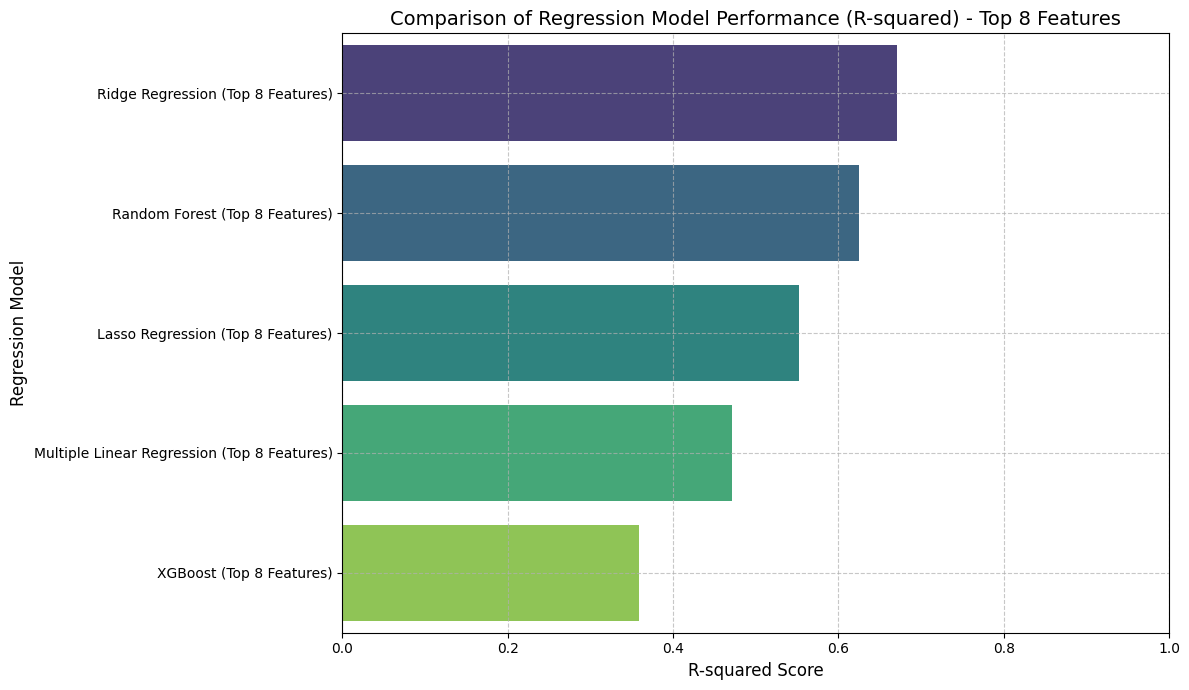

In [ ]:
# GRAFICO DE COMPARACION DE MODELOS CON R2

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Collect the R-squared values from the executed models (using top 8 features)
model_performance = {
    'Random Forest (Top 8 Features)': r2_rf_top8,
    'Multiple Linear Regression (Top 8 Features)': r2_mlr_top8,
    'XGBoost (Top 8 Features)': r2_xgb_top8,
    'Lasso Regression (Top 8 Features)': r2_lasso_top8,
    'Ridge Regression (Top 8 Features)': r2_ridge_top8
}

# Create a DataFrame for easy plotting
performance_df = pd.DataFrame(list(model_performance.items()), columns=['Model', 'R-squared'])

# Sort the DataFrame by R-squared for better visualization
performance_df = performance_df.sort_values(by='R-squared', ascending=False)

# Create the bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x='R-squared', y='Model', hue='Model', data=performance_df, palette='viridis', legend=False)
plt.xlabel('R-squared Score', fontsize=12)
plt.ylabel('Regression Model', fontsize=12)
plt.title('Comparison of Regression Model Performance (R-squared) - Top 8 Features', fontsize=14)
plt.xlim(0, 1) # R-squared typically ranges from 0 to 1
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**RESULTADOS**

**1. Análisis de Componentes Principales (PCA)**

Primero se estandarizaron las variables numéricas seleccionadas para asegurar que todas tuvieran el mismo peso en el análisis. Con esta matriz estandarizada, se aplicó PCA sobre las 8 variables top y se encontró que los dos primeros componentes explican una proporción significativa de la varianza total del sistema. A partir de este análisis se generó un biplot, el cual permitió visualizar las relaciones entre las variables seleccionadas y su contribución a los componentes principales (PC1 y PC2). Este resultado facilitó la interpretación multidimensional del conjunto de pozos y permitió identificar patrones relevantes entre propiedades petrofísicas y parámetros de completamiento.

**2. Modelos de Clustering**

Con los datos transformados mediante PCA, se aplicó nuevamente el método del codo, el cual indicó que el número óptimo de grupos para el algoritmo K‑Means era K = 3. Al ejecutar K‑Means con este valor, los datos se agruparon en tres clústeres claramente diferenciados dentro del plano PC1–PC2, lo que evidenció patrones consistentes entre condiciones de roca y diseño de completamiento.
Además, se construyó un dendrograma jerárquico, el cual confirmó la existencia de tres agrupaciones principales dentro del dataset. Este resultado fue consistente con la estructura observada en el espacio PCA y respaldó la selección de K = 3 como el número adecuado de clústeres para representar la heterogeneidad del conjunto de pozos.

**3. Modelos de Regresión**

Para la etapa predictiva, se dividieron los datos en entrenamiento (80%) y prueba (20%), y se evaluaron distintos modelos utilizando las ocho variables seleccionadas previamente. Los resultados obtenidos (R² en el conjunto de prueba) evidencian diferencias importantes en el desempeño entre los algoritmos evaluados. En términos de R², los modelos presentaron el siguiente comportamiento:

Ridge Regression: R² ≈ 0.66
Random Forest: R² ≈ 0.62
Lasso Regression: R² ≈ 0.57
Regresión lineal múltiple: R² ≈ 0.49
XGBoost: R² ≈ 0.36

El modelo Ridge Regression obtuvo el mejor desempeño general, superando ligeramente al modelo Random Forest, el cual también mostró una capacidad predictiva sólida al capturar relaciones no lineales entre las variables de entrada. Por su parte, Lasso Regression ofreció un rendimiento competitivo y estable, contribuyendo además con selección automática de variables gracias a su regularización L1. La regresión lineal múltiple sirvió como modelo base, mostrando desempeño moderado. Finalmente, XGBoost presentó el rendimiento más bajo entre los modelos evaluados para este conjunto de características y tamaño muestral.